<a href="https://colab.research.google.com/github/aleakucing/PCVK26_14_IBRA/blob/main/Week5_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Muchammad Ibrahim Al Amin'
NIM = '244107020062'
N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)

print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + ' ' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Muchammad Ibrahim Al Amin
NIM : 244107020062 | N = 62
bins   : 32
clip   : 2.0
tile   : 4
L      : 8
WAKTU  : 2026-09-27 16:06:25 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 13641e73f8a723ba


**E-1 PERCOBAAN HISTOGRAM**

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import glob



In [61]:
CONTOH = '/content/drive/MyDrive/PCVK_2026/Minggu 5'
BASE = '/content/drive/MyDrive/PCVK_2026/Images/' + NIM

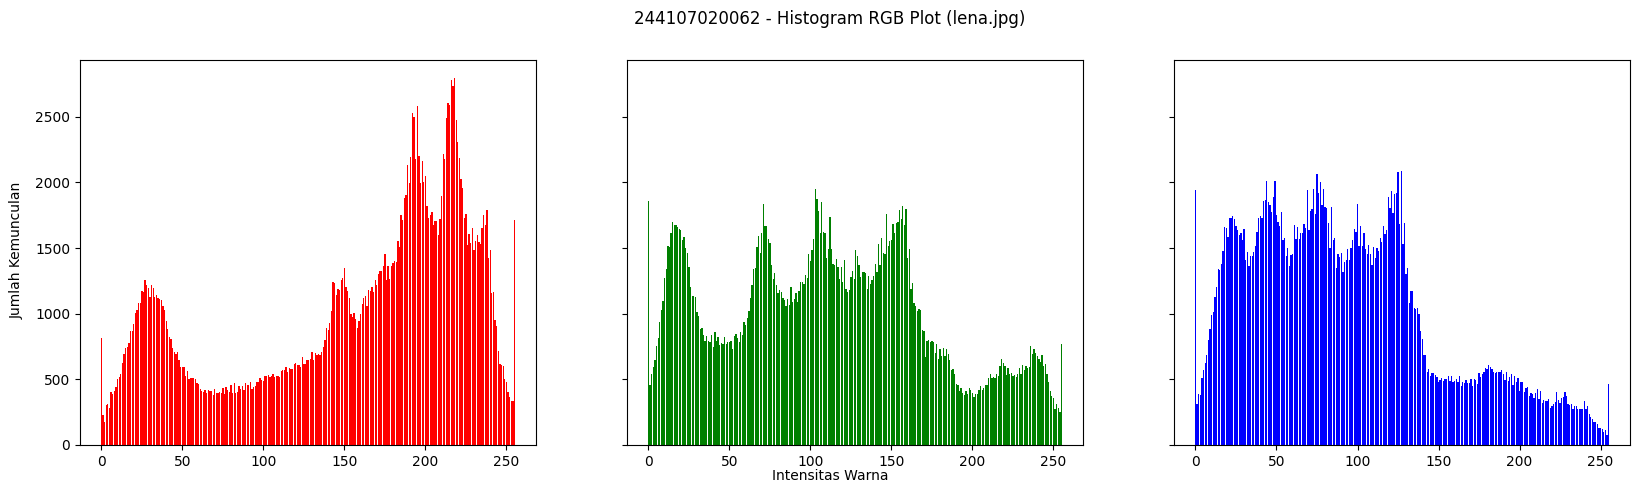

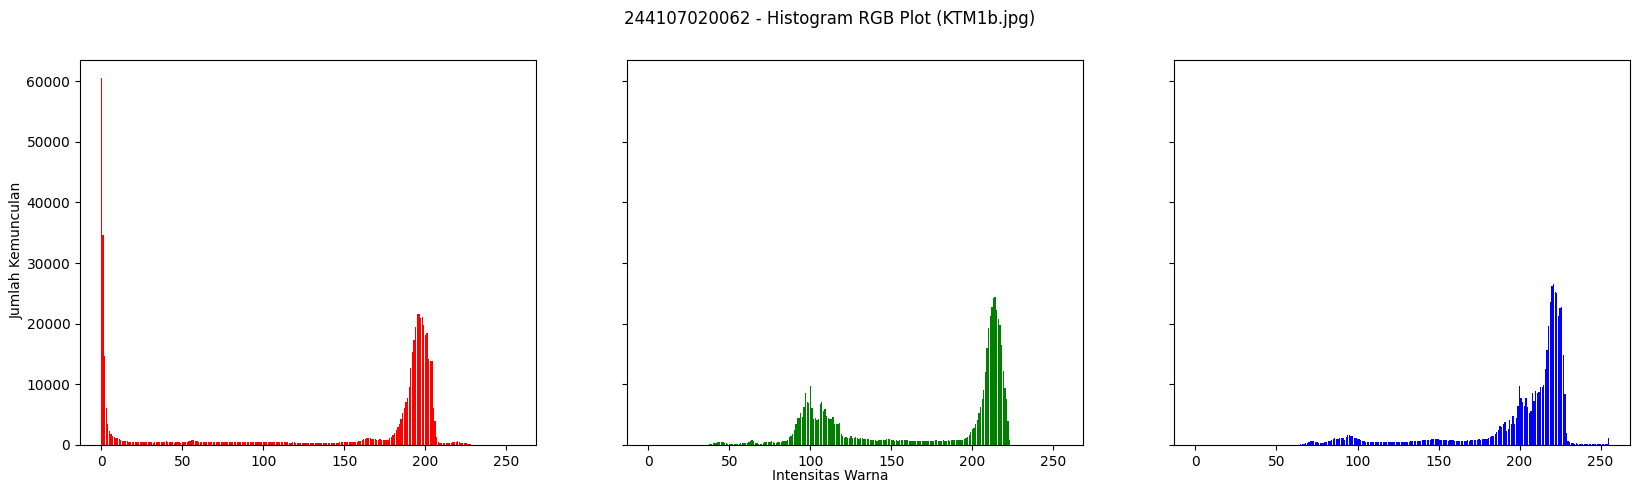

In [62]:
img_lena = cv.imread(CONTOH + '/lena.jpg')
img_lena = cv.cvtColor(img_lena, cv.COLOR_BGR2RGB)

height, width, _ = np.shape(img_lena)
names = np.arange(256)
red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(height):
    for x in range(width):
        red[img_lena[y][x][0]] += 1
        green[img_lena[y][x][1]] += 1
        blue[img_lena[y][x][2]] += 1

fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle(f"{NIM} - Histogram RGB Plot (lena.jpg)")
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

img_ktm = cv.imread(BASE + '/KTM1b.jpg')
img_ktm = cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB)

height, width, _ = np.shape(img_ktm)
red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(height):
    for x in range(width):
        red[img_ktm[y][x][0]] += 1
        green[img_ktm[y][x][1]] += 1
        blue[img_ktm[y][x][2]] += 1

fig, axs = plt.subplots(1, 3, figsize=[20, 5], sharex=True, sharey=True)
fig.suptitle(f"{NIM} - Histogram RGB Plot (KTM1b.jpg)")
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [63]:
def histogram_manual(img_gray, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img_gray.shape[0]):
        for x in range(img_gray.shape[1]):
            h[img_gray[y, x]] += 1
    return h

def verifikasi_histogram(path_gambar, label):
    img = cv.imread(path_gambar, cv.IMREAD_GRAYSCALE)
    if img is None:
        print(f"File {path_gambar} tidak ditemukan.")
        return

    h_manual = histogram_manual(img)
    h_numpy, _ = np.histogram(img.flatten(), bins=256, range=[0, 256])
    h_cv = cv.calcHist([img], [0], None, [256], [0, 256]).flatten().astype(np.int64)

    diff1 = np.max(np.abs(h_manual - h_numpy))
    diff2 = np.max(np.abs(h_manual - h_cv))
    print(f"[{label}] Selisih maks Manual vs NumPy : {diff1}")
    print(f"[{label}] Selisih maks Manual vs OpenCV: {diff2}")

verifikasi_histogram(CONTOH + '/lena.jpg', 'lena.jpg')
verifikasi_histogram(BASE + '/KTM1b.jpg', 'KTM1b.jpg')

[lena.jpg] Selisih maks Manual vs NumPy : 0
[lena.jpg] Selisih maks Manual vs OpenCV: 0
[KTM1b.jpg] Selisih maks Manual vs NumPy : 0
[KTM1b.jpg] Selisih maks Manual vs OpenCV: 0


2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

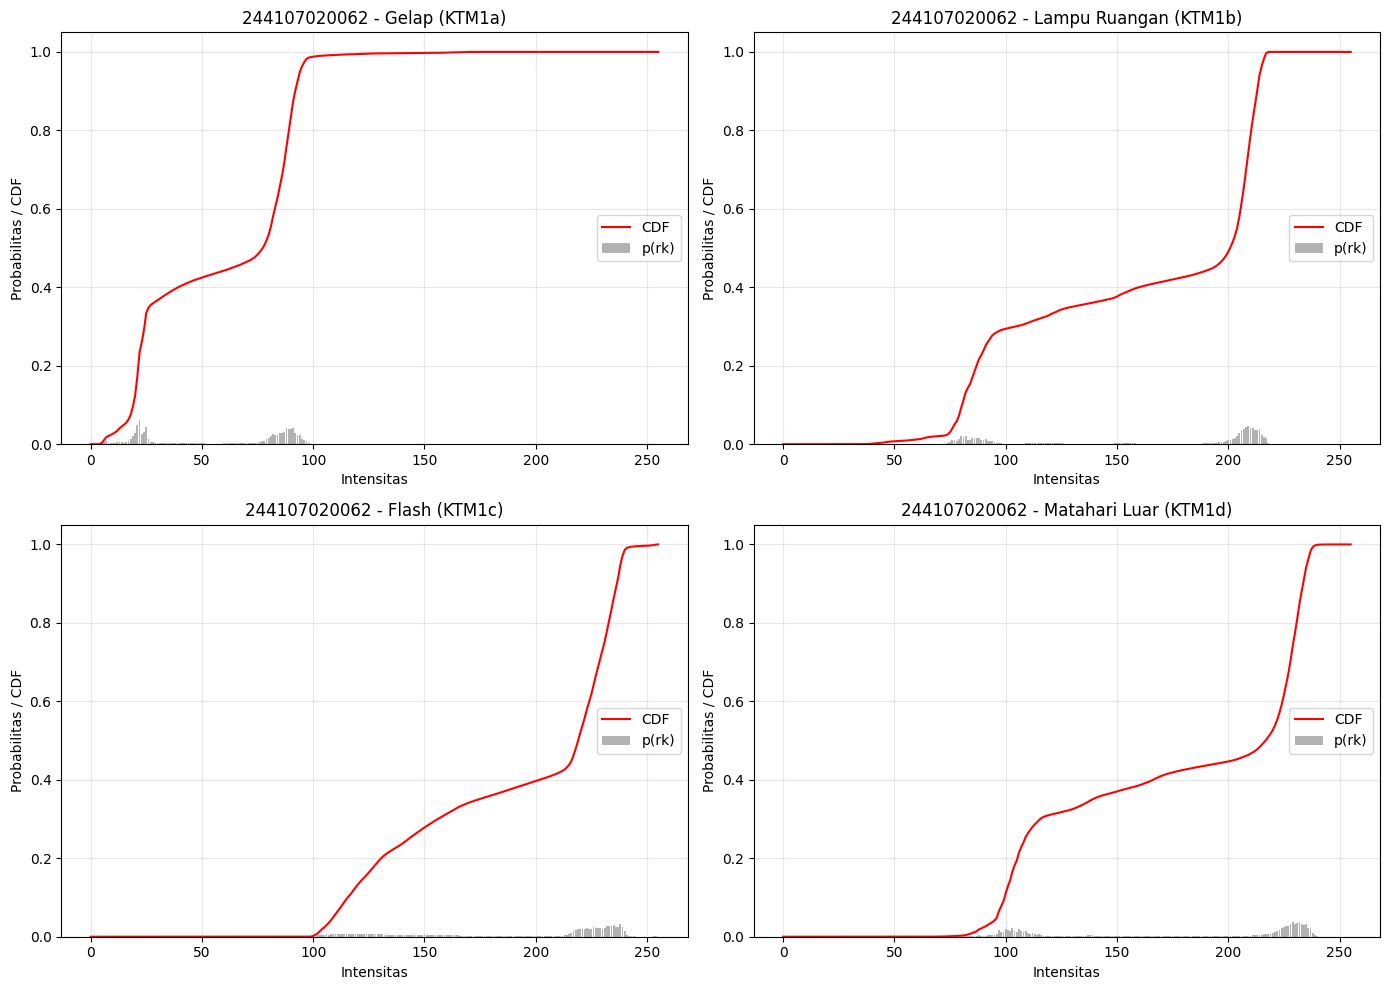

In [64]:
citra_list = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
label_kondisi = ['Gelap (KTM1a)', 'Lampu Ruangan (KTM1b)', 'Flash (KTM1c)', 'Matahari Luar (KTM1d)']

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
for idx, fname in enumerate(citra_list):
    ax = axs[idx // 2, idx % 2]
    img = cv.imread(f"{BASE}/{fname}", cv.IMREAD_GRAYSCALE)
    if img is not None:
        h = cv.calcHist([img], [0], None, [256], [0, 256]).flatten()
        p = h / img.size
        cdf = np.cumsum(p)

        ax.bar(np.arange(256), p, color='gray', alpha=0.6, label='p(rk)')
        ax.plot(cdf, color='red', linewidth=1.5, label='CDF')
        ax.set_title(f"{NIM} - {label_kondisi[idx]}")
        ax.set_xlabel('Intensitas')
        ax.set_ylabel('Probabilitas / CDF')
        ax.legend(loc='center right')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Analisis**
- Pada citra KTM1a.jpg, Fotonya minim cahaya, jadi mayoritas piksel bernilai rendah (mendekati 0/hitam). Akibatnya grafik CDF langsung naik tajam di awal dan cepat mendatar di atas. naik dengan sangat curam di awal rentang intensitas rendah dan cepat mendatar menuju nilai 1.0 sebelum mencapai intensitas 255.
- Pada citra KTM1d.jpg terkena cahaya matahari langsung, jadi pikselnya banyak yang bernilai tinggi (mendekati 255/putih). Makanya grafik CDF landai di awal dan baru naik tajam di bagian akhir
- Hal ini sesuai dengan kondisi pencahayaan saat akuisisi: ruangan gelap tanpa cahaya langsung menghasilkan akumulasi energi pencahayaan yang sangat minim pada sensor kamera, sedangkan pencahayaan matahari luar ruangan memberikan saturasi intensitas foton tinggi ke seluruh permukaan kartu.

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

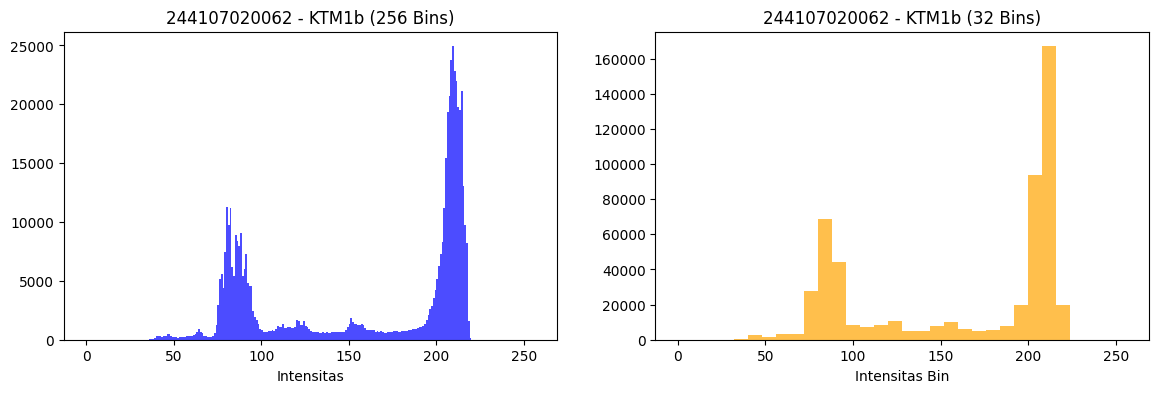

In [65]:
img_ktm1b = cv.imread(f"{BASE}/KTM1b.jpg", cv.IMREAD_GRAYSCALE)
if img_ktm1b is not None:
    bins_custom = PARAM['bins']

    fig, axs = plt.subplots(1, 2, figsize=(14, 4))

    axs[0].hist(img_ktm1b.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
    axs[0].set_title(f"{NIM} - KTM1b (256 Bins)")
    axs[0].set_xlabel('Intensitas')

    axs[1].hist(img_ktm1b.ravel(), bins=bins_custom, range=[0, 256], color='orange', alpha=0.7)
    axs[1].set_title(f"{NIM} - KTM1b ({bins_custom} Bins)")
    axs[1].set_xlabel('Intensitas Bin')

    plt.show()

 **Analisis:**
 - detail citra KTM1b.jpg gradasi warna halus jadi hilang. Nilai piksel yang mirip dikelompokkan ke satu kelompok besar yang sama, sehingga grafik terlihat lebih kasar dan perbedaan intensitas kecil tidak terbaca lagi.

**E-2 PERCOBAAN HISTOGRAM EQUALIZATION**

1. Implementasi Histogram Equalization Manual

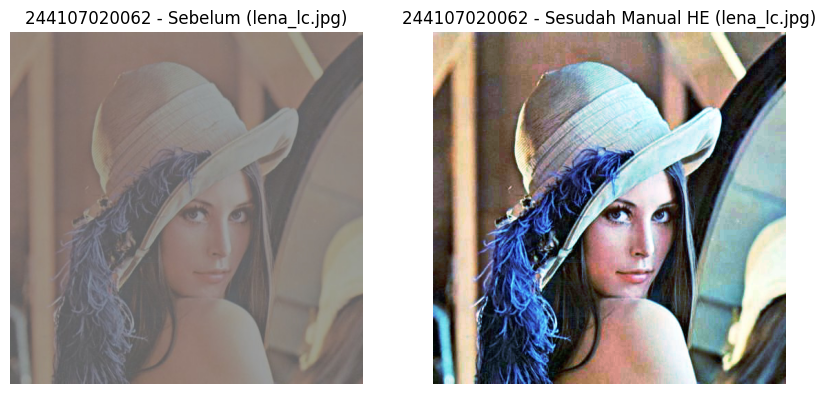

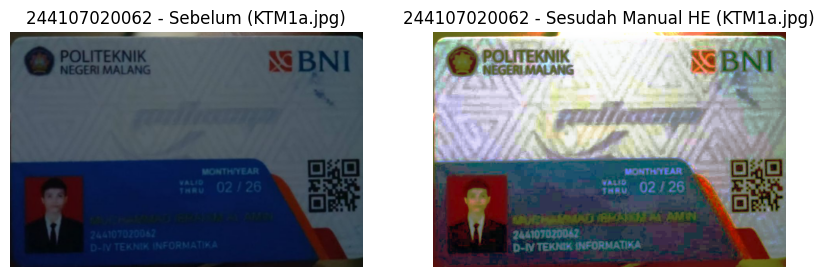

In [66]:
def he_manual_channel(ch):
    hist, _ = np.histogram(ch.flatten(), bins=256, range=[0, 256])
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    sk = (cdf_m - cdf_m.min()) * 255 / (ch.size - cdf_m.min())
    sk = np.ma.filled(sk, 0)
    lut = np.round(sk).astype(np.uint8)
    return lut[ch]

def he_manual_bgr(img):
    b, g, r = cv.split(img)
    return cv.merge([he_manual_channel(b), he_manual_channel(g), he_manual_channel(r)])

lena_lc = cv.imread(CONTOH + '/lena_lc.jpg')
lena_he_manual = he_manual_bgr(lena_lc)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(lena_lc, cv.COLOR_BGR2RGB))
axs[0].set_title(f"{NIM} - Sebelum (lena_lc.jpg)")
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(lena_he_manual, cv.COLOR_BGR2RGB))
axs[1].set_title(f"{NIM} - Sesudah Manual HE (lena_lc.jpg)")
axs[1].axis('off')
plt.show()

ktm1a = cv.imread(BASE + '/KTM1a.jpg')
ktm1a_he_manual = he_manual_bgr(ktm1a)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(ktm1a, cv.COLOR_BGR2RGB))
axs[0].set_title(f"{NIM} - Sebelum (KTM1a.jpg)")
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(ktm1a_he_manual, cv.COLOR_BGR2RGB))
axs[1].set_title(f"{NIM} - Sesudah Manual HE (KTM1a.jpg)")
axs[1].axis('off')
plt.show()

2. Bandingkan dengan cv.equalizeHist, dan hitung PSNR

In [67]:
def he_cv_bgr(image):
    b, g, r = cv.split(image)
    b_equalized = cv.equalizeHist(b)
    g_equalized = cv.equalizeHist(g)
    r_equalized = cv.equalizeHist(r)
    return cv.merge([b_equalized, g_equalized, r_equalized])

lena_he_cv = he_cv_bgr(lena_lc)
selisih_lena = np.max(np.abs(lena_he_manual.astype(np.int32) - lena_he_cv.astype(np.int32)))
print("Selisih maksimum Manual vs cv.equalizeHist pada lena_lc.jpg :", selisih_lena)

ktm1a_he_cv = he_cv_bgr(ktm1a)
selisih_ktm = np.max(np.abs(ktm1a_he_manual.astype(np.int32) - ktm1a_he_cv.astype(np.int32)))
print("Selisih maksimum Manual vs cv.equalizeHist pada KTM1a.jpg   :", selisih_ktm)

Selisih maksimum Manual vs cv.equalizeHist pada lena_lc.jpg : 0
Selisih maksimum Manual vs cv.equalizeHist pada KTM1a.jpg   : 0


3. Ekualisasi Kanal Mandiri B, G, R dan 4. Geser Hue

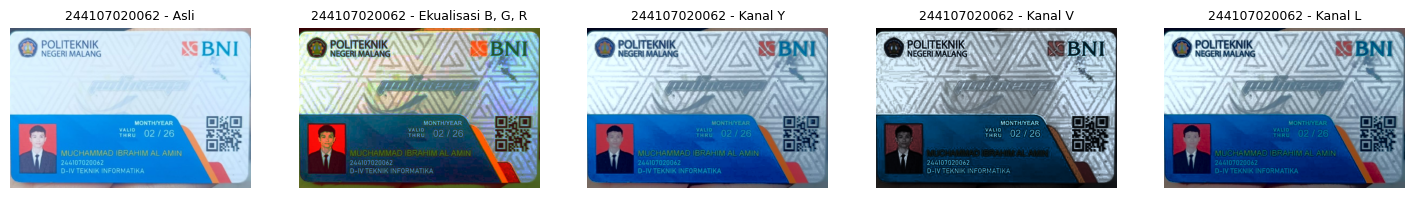

Cara                   geser Hue (der)    rerata terang   
Asli                   0.00               179.2           
Ekualisasi B, G, R     54.82              126.3           
Kanal Y                3.92               134.0           
Kanal V                1.46               109.6           
Kanal L                5.00               122.9           


In [68]:
bgr_lena = cv.imread(CONTOH + '/lena.jpg')
kanal_lena = list(cv.split(bgr_lena))
for i in range(3):
    kanal_lena[i] = cv.equalizeHist(kanal_lena[i])
he_rgb_lena = cv.merge(kanal_lena)

bgr_ktm = cv.imread(BASE + '/KTM1d.jpg')
kanal_ktm = list(cv.split(bgr_ktm))
for i in range(3):
    kanal_ktm[i] = cv.equalizeHist(kanal_ktm[i])
he_rgb_ktm = cv.merge(kanal_ktm)

ycrcb = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

hsv = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2LAB)
l, a, b_lab = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b_lab]), cv.COLOR_LAB2BGR)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr_ktm, he_rgb_ktm, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(f"{NIM} - {t}", fontsize=9)
    plt.axis('off')
plt.show()

def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()

print(f"{'Cara':<22} {'geser Hue (der)':<18} {'rerata terang':<16}")
for t, c in zip(judul, citra):
    g_hue = geser_hue(bgr_ktm, c) * 2
    r_terang = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    print(f"{t:<22} {g_hue:<18.2f} {r_terang:<16.1f}")

In [69]:
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

lab_clahe = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2LAB)
l_c, a_c, b_c = cv.split(lab_clahe)
he_l_clahe = cv.cvtColor(cv.merge([clahe.apply(l_c), a_c, b_c]), cv.COLOR_LAB2BGR)

print(f"LAB Biasa - Geser Hue: {geser_hue(bgr_ktm, he_l)*2:.2f} | Rerata Terang: {cv.cvtColor(he_l, cv.COLOR_BGR2GRAY).mean():.1f}")
print(f"LAB CLAHE - Geser Hue: {geser_hue(bgr_ktm, he_l_clahe)*2:.2f} | Rerata Terang: {cv.cvtColor(he_l_clahe, cv.COLOR_BGR2GRAY).mean():.1f}")

LAB Biasa - Geser Hue: 5.00 | Rerata Terang: 122.9
LAB CLAHE - Geser Hue: 1.28 | Rerata Terang: 167.7


**PERTANYAAN PRAKTIKUM E2**

1. Ekualisasi global pada citra KTM Anda
    
    a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi
    grayscale.
    
    b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

    

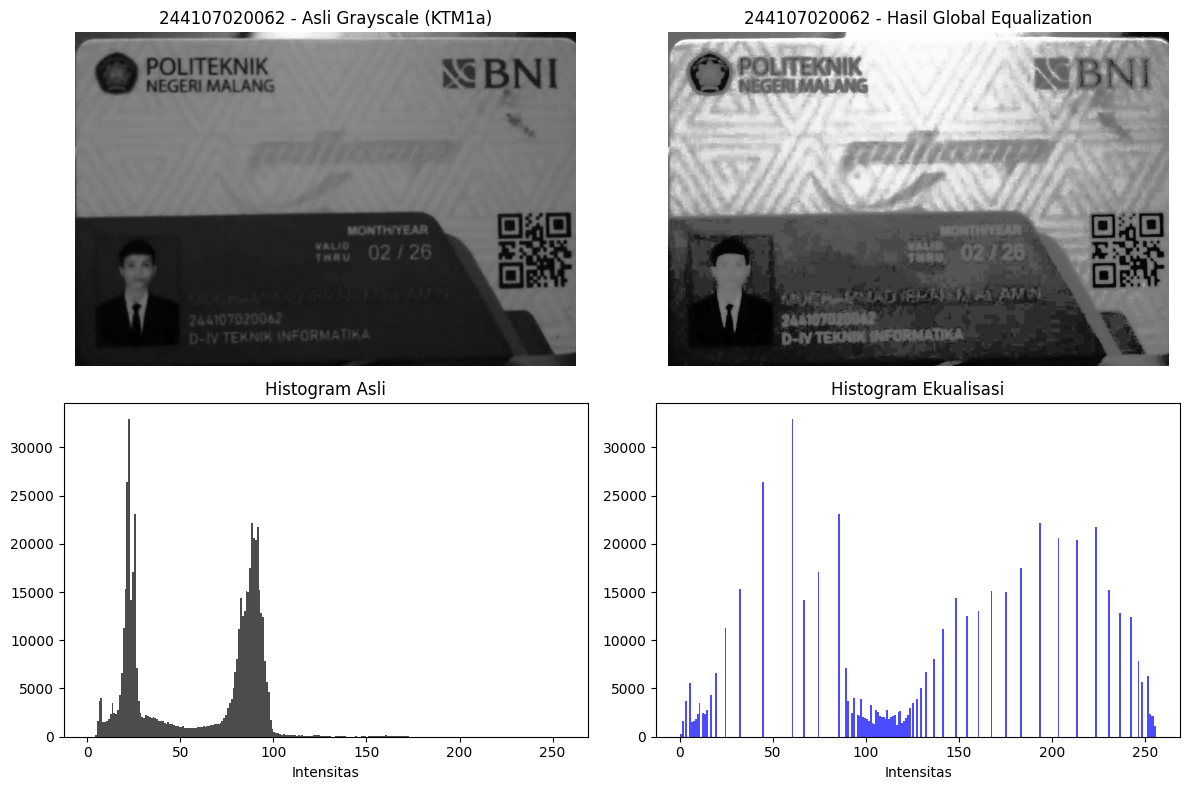

In [70]:
ktm_gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
ktm_gray_manual = he_manual_channel(ktm_gray)
ktm_gray_cv = cv.equalizeHist(ktm_gray)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].imshow(ktm_gray, cmap='gray')
axs[0, 0].set_title(f"{NIM} - Asli Grayscale (KTM1a)")
axs[0, 0].axis('off')

axs[0, 1].imshow(ktm_gray_cv, cmap='gray')
axs[0, 1].set_title(f"{NIM} - Hasil Global Equalization")
axs[0, 1].axis('off')

axs[1, 0].hist(ktm_gray.ravel(), bins=256, range=[0, 256], color='black', alpha=0.7)
axs[1, 0].set_title("Histogram Asli")
axs[1, 0].set_xlabel("Intensitas")

axs[1, 1].hist(ktm_gray_cv.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
axs[1, 1].set_title("Histogram Ekualisasi")
axs[1, 1].set_xlabel("Intensitas")

plt.tight_layout()
plt.show()

In [71]:
#c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR layak dipakai untuk menilai keterbacaan sebuah citra.
psnr_val = cv.PSNR(ktm_gray, ktm_gray_cv)
print(f"Nilai PSNR antara Citra Asli dan Hasil Ekualisasi: {psnr_val:.2f} dB")

Nilai PSNR antara Citra Asli dan Hasil Ekualisasi: 9.65 dB


**Analisis**
- Penyebab PSNR turun: PSNR mengukur perbedaan angka piksel antara citra asli dan citra hasil. Karena ekualisasi sengaja mengubah warna gelap menjadi terang, selisih angka pikselnya jadi sangat besar.
- Kesimpulan PSNR tidak layak dipakai untuk menilai keterbacaan citra, karena nilai PSNR hanya mengukur kemiripan angka piksel fisik, bukan kejelasan teks di mata manusia[cite: 1].

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda"

    a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan
    tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi
    global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

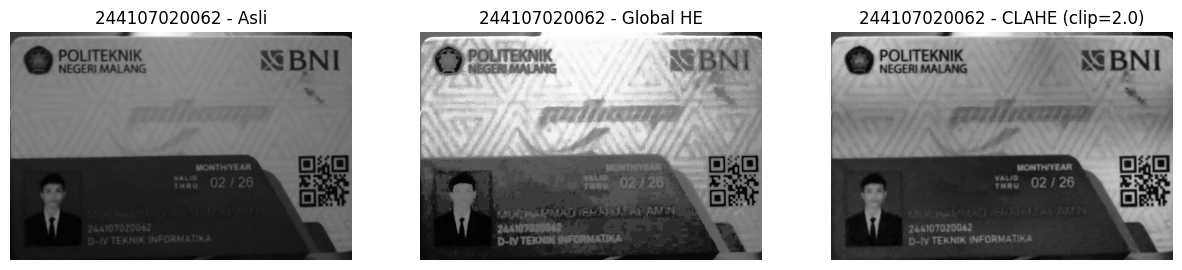

In [72]:
clahe_main = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)
ktm_clahe = clahe_main.apply(ktm_gray)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(ktm_gray, cmap='gray')
axs[0].set_title(f"{NIM} - Asli")
axs[0].axis('off')

axs[1].imshow(ktm_gray_cv, cmap='gray')
axs[1].set_title(f"{NIM} - Global HE")
axs[1].axis('off')

axs[2].imshow(ktm_clahe, cmap='gray')
axs[2].set_title(f"{NIM} - CLAHE (clip={PARAM['clip']})")
axs[2].axis('off')
plt.show()

- Bagian NIM dan nama jauh lebih mudah dibaca pada hasil CLAHE[cite: 1].
- Ekualisasi global membuat latar belakang terlalu silau/terang sehingga tulisan kabur bercampur latar[cite: 1], sedangkan CLAHE hanya memperjelas kontras di sekitar huruf teks saja[cite: 1].

b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu
    tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang noise-nya mulai menonjol ketika clipLimit dinaikkan.

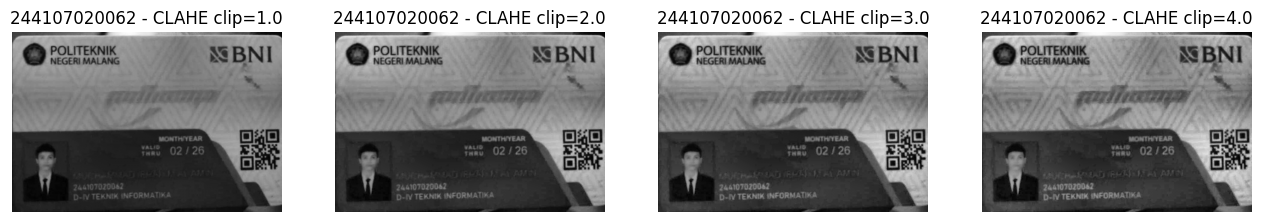

In [73]:
clip_base = PARAM['clip']
variasi_clip = [round(max(1.0, clip_base - 1.0), 1), clip_base, round(clip_base + 1.0, 1), round(clip_base + 2.0, 1)]

plt.figure(figsize=(16, 4))
for idx, c_val in enumerate(variasi_clip, 1):
    c_obj = cv.createCLAHE(clipLimit=c_val, tileGridSize=(PARAM['tile'], PARAM['tile']))
    res = c_obj.apply(ktm_gray)
    plt.subplot(1, 4, idx)
    plt.imshow(res, cmap='gray')
    plt.title(f"{NIM} - CLAHE clip={c_val}")
    plt.axis('off')
plt.show()

- Nilai terbaik: Nilai terbaik adalah pada PARAM['clip'] (2.0)[cite: 1, 2], karena tulisan sudah jelas dan latarnya masih bersih[cite: 1].
- Kemunculan noise: Saat clipLimit dinaikkan ke 3.0 dan 4.0, bintik-bintik derau (noise) mulai tampak kasar di area latar belakang kartu dan bagian pasfoto[cite: 1].

**E-3 TUGAS PRAKTIKUM DITHERING**

In [74]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * (7 / 16)
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3 / 16)
            if y + 1 < H:
                img[y + 1, x] += error * (5 / 16)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1 / 16)
    return np.clip(img, 0, 255).astype(np.uint8)

def dithering_bgr(img_bgr, L):
    b, g, r = cv.split(img_bgr)
    b_dit = floyd_steinberg(b, L=L)
    g_dit = floyd_steinberg(g, L=L)
    r_dit = floyd_steinberg(r, L=L)
    return cv.merge([b_dit, g_dit, r_dit])

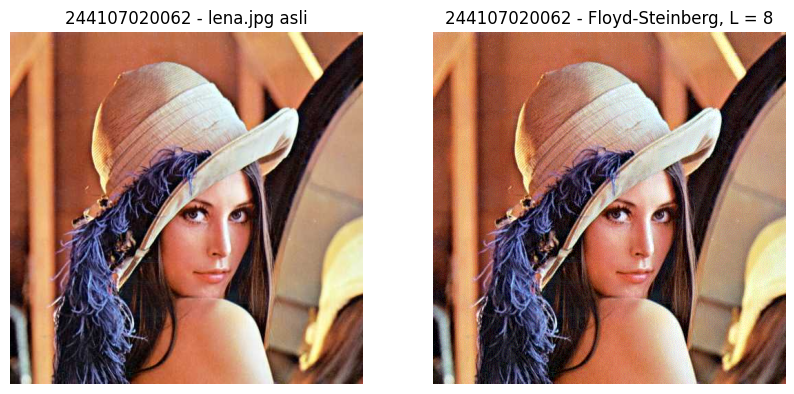

In [75]:
lena_bgr = cv.imread(CONTOH + '/lena.jpg')
lena_dit = dithering_bgr(lena_bgr, L=PARAM['L'])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(lena_bgr, cv.COLOR_BGR2RGB))
axs[0].set_title(f"{NIM} - lena.jpg asli")
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(lena_dit, cv.COLOR_BGR2RGB))
axs[1].set_title(f"{NIM} - Floyd-Steinberg, L = {PARAM['L']}")
axs[1].axis('off')
plt.show()

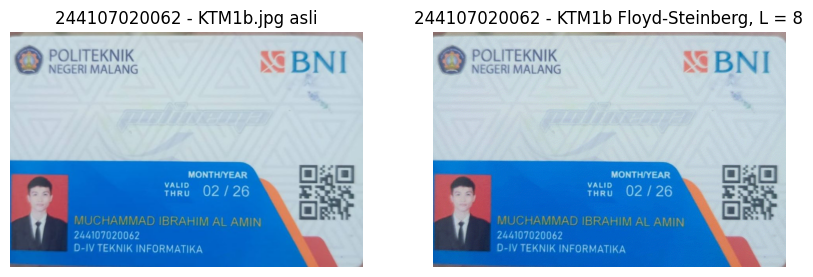

In [76]:
ktm1b_bgr = cv.imread(BASE + '/KTM1b.jpg')
ktm1b_dit = dithering_bgr(ktm1b_bgr, L=PARAM['L'])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(cv.cvtColor(ktm1b_bgr, cv.COLOR_BGR2RGB))
axs[0].set_title(f"{NIM} - KTM1b.jpg asli")
axs[0].axis('off')

axs[1].imshow(cv.cvtColor(ktm1b_dit, cv.COLOR_BGR2RGB))
axs[1].set_title(f"{NIM} - KTM1b Floyd-Steinberg, L = {PARAM['L']}")
axs[1].axis('off')
plt.show()

2. Ubah citra ke grayscale, terapkan perbandingan 4 tampilan: citra asli, dithering langsung, hasil ekualisasi, dan ekualisasi lalu dithering

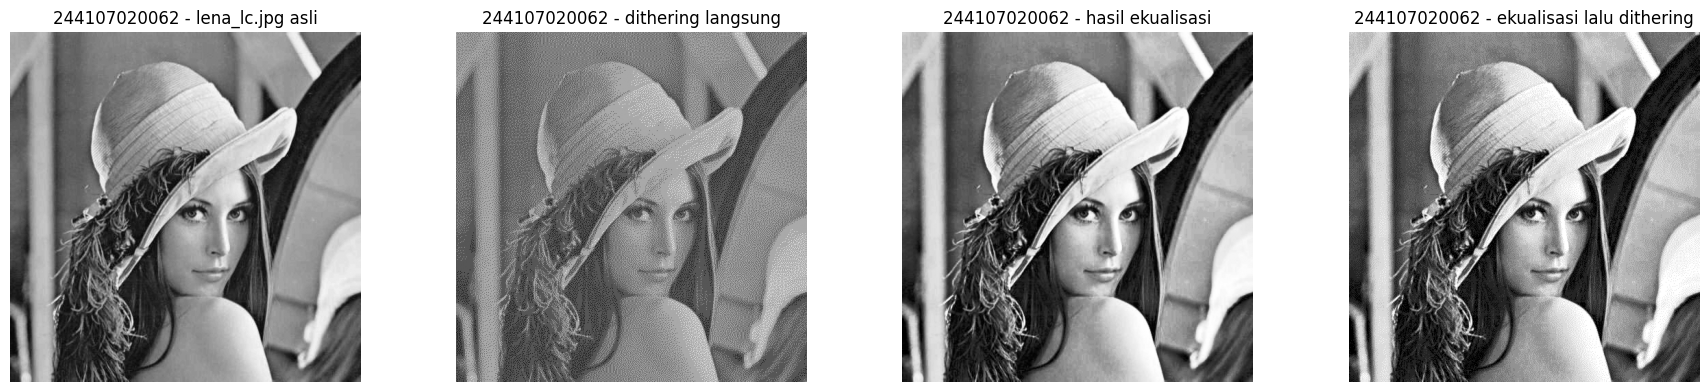

In [77]:
lena_lc_gray = cv.imread(CONTOH + '/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
dit_langsung_lena = floyd_steinberg(lena_lc_gray, L=PARAM['L'])
he_lena = cv.equalizeHist(lena_lc_gray)
he_dit_lena = floyd_steinberg(he_lena, L=PARAM['L'])

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
axs[0].imshow(lena_lc_gray, cmap='gray')
axs[0].set_title(f"{NIM} - lena_lc.jpg asli")
axs[0].axis('off')

axs[1].imshow(dit_langsung_lena, cmap='gray')
axs[1].set_title(f"{NIM} - dithering langsung")
axs[1].axis('off')

axs[2].imshow(he_lena, cmap='gray')
axs[2].set_title(f"{NIM} - hasil ekualisasi")
axs[2].axis('off')

axs[3].imshow(he_dit_lena, cmap='gray')
axs[3].set_title(f"{NIM} - ekualisasi lalu dithering")
axs[3].axis('off')

plt.tight_layout()
plt.show()

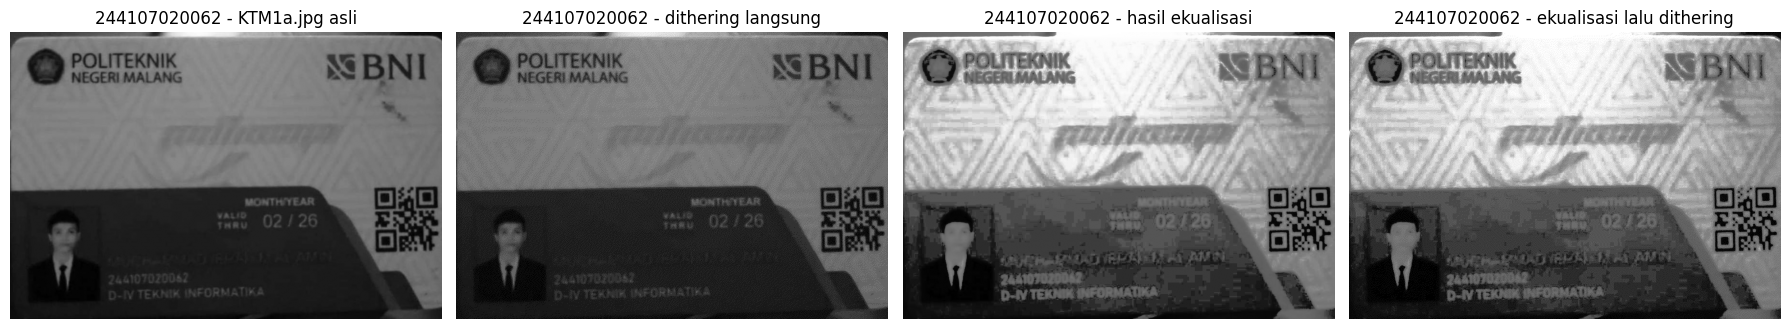

In [78]:
ktm1a_gray = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
dit_langsung_ktm = floyd_steinberg(ktm1a_gray, L=PARAM['L'])
he_ktm = cv.equalizeHist(ktm1a_gray)
he_dit_ktm = floyd_steinberg(he_ktm, L=PARAM['L'])

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
axs[0].imshow(ktm1a_gray, cmap='gray')
axs[0].set_title(f"{NIM} - KTM1a.jpg asli")
axs[0].axis('off')

axs[1].imshow(dit_langsung_ktm, cmap='gray')
axs[1].set_title(f"{NIM} - dithering langsung")
axs[1].axis('off')

axs[2].imshow(he_ktm, cmap='gray')
axs[2].set_title(f"{NIM} - hasil ekualisasi")
axs[2].axis('off')

axs[3].imshow(he_dit_ktm, cmap='gray')
axs[3].set_title(f"{NIM} - ekualisasi lalu dithering")
axs[3].axis('off')

plt.tight_layout()
plt.show()

**Analisis:**
- Urutan terbaik: Teks pada KTM jauh lebih mudah dibaca pada urutan Ekualisasi lalu Dithering[cite: 1].
- Alasannya: Pada citra KTM1a, jika langsung dilakukan dithering, perbedaan nilai piksel antara tulisan dan latar belakang masih sangat kecil, sehingga keduanya sama-sama terpotong menjadi titik-titik gelap dan teks menjadi hilang/sulit dibaca[cite: 1]. Sedangkan jika diekualisasi terlebih dahulu, kontras antara teks dan latar kartu diperlebar, sehingga pola error diffusion dithering mampu merekonstruksi bentuk huruf teks dengan tajam dan jelas[cite: 1].